# **Logistic Regresion**

```scikit-learn``` webpage [here](https://scikit-learn.org/stable/index.html) \
```Iris``` dataset description [here](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html#sklearn.datasets.load_iris) \
```LogisticRegression``` documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html?highlight=logistic%20regression#sklearn.linear_model.LogisticRegression)

### In Synthetic data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

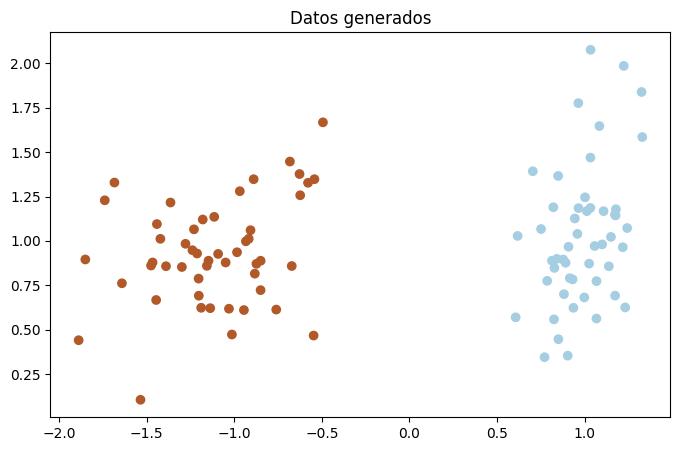

In [ ]:
# Crear dataset de clasificación sintético
X, y = make_classification(n_samples=100, n_features=2, n_redundant=0,
                           n_informative=2, n_clusters_per_class=1, n_classes=2,
                           random_state=1)

# Graficar datos originales
_, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='Paired')
ax.set_title("Datos generados")
plt.show()

In [ ]:
# Create an instance
logistic_regression = LogisticRegression()

# Train the model
logistic_regression.fit ( X , y ) #(# Samples, # Features)

LogisticRegression()

In [ ]:
# predicciones para ajustar el modelo
predictions = logistic_regression.predict(X)
print (predictions)

[1 0 0 1 1 1 0 1 0 1 0 0 0 0 0 0 1 1 1 1 1 0 1 0 0 1 0 0 0 1 1 1 1 0 0 1 0
 0 0 0 1 1 0 0 1 0 1 1 0 1 1 0 1 1 1 0 0 0 1 1 0 0 1 0 0 1 0 0 0 1 0 0 0 1
 1 1 0 1 1 1 0 0 0 1 1 1 0 1 1 1 0 1 0 0 1 0 1 1 0 1]


### **Decision boundaries**

In [ ]:
# Min-Max values for the grid of decision boundaries (encontrar valores de los ejes vert y hori)
# Unidimensional
h_min, h_max = X[:, 0].min() - 1, X[:, 0].max() + 1
v_min, v_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# Create grid
h_grid, v_grid = np.meshgrid(
    np.linspace(h_min, h_max, 100),
    np.linspace(v_min, v_max, 100)
)
print("points", h_grid.shape, v_grid.shape)

#vector unidimensional
print (h_grid.ravel().shape, v_grid.ravel().shape)
print (np.c_[h_grid.ravel(), v_grid.ravel()].shape)

# Estimate predictions over the grid
predictions = logistic_regression.predict(np.c_[h_grid.ravel(), v_grid.ravel()]) #concatena a lo largo
print (predictions.shape)

#entregar tamano para dimensionar a predictions de h_grid
# Reshape predictions
predictions = predictions.reshape(h_grid.shape)
print (predictions.shape)

points (100, 100) (100, 100)
(10000,) (10000,)
(10000, 2)
(10000,)
(100, 100)


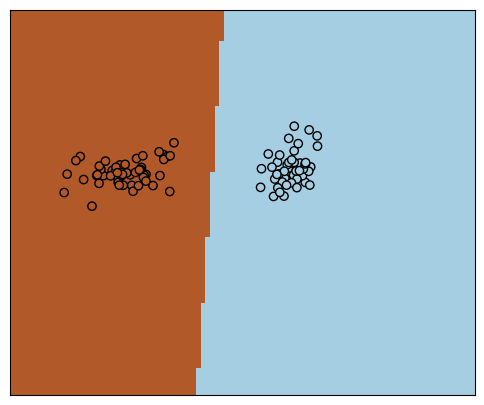

In [ ]:
# Draw grid
fig, ax = plt.subplots(figsize=(6, 5))
ax.pcolormesh(h_grid, v_grid, predictions, cmap='Paired', shading='auto')

# Scatter real values
# Dar forma al vector de predicciones para que coincida con el grid
ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='Paired')

ax.set_xticks(())
ax.set_yticks(())
plt.show()
# cuando los colores van al otro extremo de colores son errores
# cuando dos grupos se pueden separar por una linea se llaman linealmente separables


### In Real data

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris

In [11]:
iris = load_iris() # Load iris dataset
iris_X = iris.data # Features
iris_y = iris.target # Labels

# Imprimir formas
print (iris_X.shape, iris_y.shape)

(150, 4) (150,)


In [21]:
# Create an instance
logistic_regression = LogisticRegression(max_iter = 5000)

# Train the model using only the first two features
logistic_regression.fit(iris_X[:, :2], iris_y)

LogisticRegression(max_iter=5000)

In [22]:
# Min-Max values for the grid of decision boundaries
X_min, X_max = iris_X[:, 0].min(), iris_X[:, 0].max()
y_min, y_max = iris_X[:, 1].min(), iris_X[:, 1].max()

# Create grid
y_grid, X_grid = np.meshgrid(
    np.linspace(X_min, X_max, 100),
    np.linspace(y_min, y_max, 100)
)
print("points", y_grid.shape, X_grid.shape)

#vector unidimensional
print (y_grid.ravel().shape, X_grid.ravel().shape)
print (np.c_[y_grid.ravel(), X_grid.ravel()].shape)

# Estimate predictions over the grid
predictions = logistic_regression.predict(np.c_[y_grid.ravel(), X_grid.ravel()]) #concatena a lo largo
print (predictions.shape)


#entregar tamano para dimensionar a predictions de h_grid
# Reshape predictions
predictions = predictions.reshape(y_grid.shape)
print (predictions.shape)

points (100, 100) (100, 100)
(10000,) (10000,)
(10000, 2)
(10000,)
(100, 100)


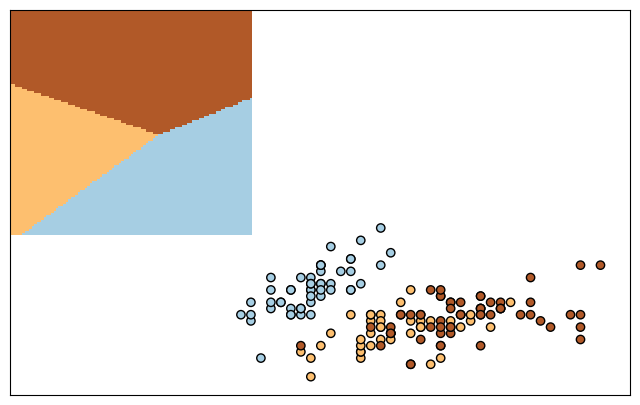

In [23]:
# Reshape predictions
predictions = predictions

# Draw grid
_, ax = plt.subplots (figsize=(8,5))
ax.pcolormesh( X_grid , y_grid , predictions , cmap = "Paired", shading='auto')

# Scatter real values
ax.scatter ( iris_X[:, 0] , iris_X[:, 1] , c = iris_y , edgecolors = 'k', cmap = "Paired")

ax.set_xticks(())
ax.set_yticks(())
plt.show()

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
